# Denoising Autoencoder - MNIST

## Step 1 - Import Libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, SubsetRandomSampler
import torchvision.datasets as ds
import torchvision.transforms as tr

## Step 2 - Load MNIST Dataset

In [2]:
convert = tr.ToTensor()

train_data = ds.MNIST('data', train=True,  download=True, transform=convert)
test_data  = ds.MNIST('data', train=False, download=True, transform=convert)

print('Total train images :', len(train_data))
print('Total test images  :', len(test_data))

Total train images : 60000
Total test images  : 10000


In [3]:
bs = 64
split = 0.15

total = len(train_data)
all_idx = list(range(total))
np.random.seed(10)
np.random.shuffle(all_idx)

v = int(total * split)
t_idx = all_idx[v:]
v_idx = all_idx[:v]

t_load = DataLoader(train_data, batch_size=bs, sampler=SubsetRandomSampler(t_idx))
v_load = DataLoader(train_data, batch_size=bs, sampler=SubsetRandomSampler(v_idx))
te_load = DataLoader(test_data,  batch_size=bs, shuffle=False)

## Step 3 - Add Noise to Images

In [4]:
amt = 0.4

def make_noisy(x):
    n = x + torch.randn_like(x) * amt
    return torch.clamp(n, 0, 1)

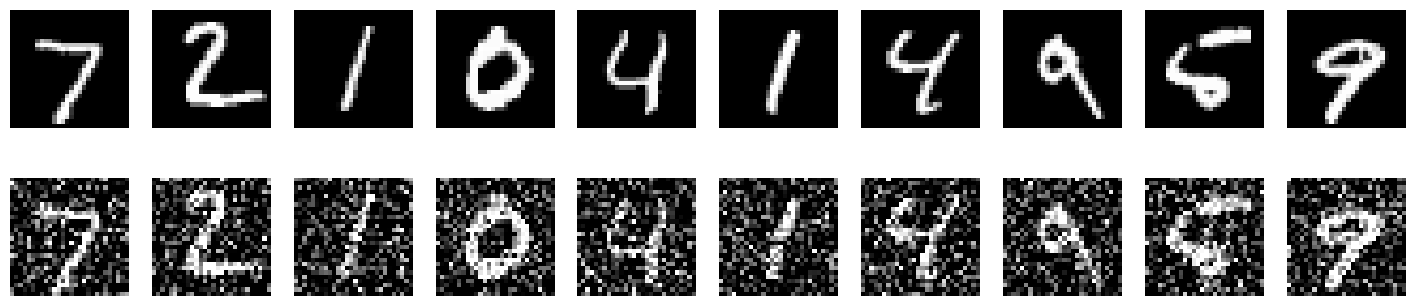

In [5]:
imgs, _ = next(iter(te_load))
noisy_imgs = make_noisy(imgs)

fig, ax = plt.subplots(2, 10, figsize=(18, 4))
for i in range(10):
    ax[0][i].imshow(imgs[i].squeeze(), cmap='gray')
    ax[0][i].axis('off')
    ax[1][i].imshow(noisy_imgs[i].squeeze(), cmap='gray')
    ax[1][i].axis('off')
ax[0][0].set_ylabel('Clean')
ax[1][0].set_ylabel('Noisy')
plt.show()

## Step 4 - Build the Autoencoder Model

In [6]:
class MyAE(nn.Module):
    def __init__(self):
        super(MyAE, self).__init__()

        self.e1 = nn.Conv2d(1, 32, 3, padding=1)
        self.e2 = nn.Conv2d(32, 64, 3, padding=1)
        self.mp = nn.MaxPool2d(2, 2)

        self.d1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.d2 = nn.ConvTranspose2d(32, 1,  2, stride=2)

    def forward(self, x):
        x = self.mp(torch.relu(self.e1(x)))
        x = self.mp(torch.relu(self.e2(x)))
        x = torch.relu(self.d1(x))
        x = torch.sigmoid(self.d2(x))
        return x


dev = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MyAE().to(dev)
print(model)

MyAE(
  (e1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (e2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (mp): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (d1): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
  (d2): ConvTranspose2d(32, 1, kernel_size=(2, 2), stride=(2, 2))
)


## Step 5 - Set Loss and Optimizer

In [7]:
err = nn.MSELoss()
opt = optim.Adam(model.parameters(), lr=0.001)
ep  = 15

## Step 6 - Train the Model

In [8]:
tr_loss = []
vl_loss = []
best = float('inf')

for e in range(1, ep + 1):

    model.train()
    tl = 0
    for x, _ in t_load:
        clean = x.to(dev)
        dirty = make_noisy(clean)
        opt.zero_grad()
        pred = model(dirty)
        loss = err(pred, clean)
        loss.backward()
        opt.step()
        tl += loss.item()

    model.eval()
    vl = 0
    with torch.no_grad():
        for x, _ in v_load:
            clean = x.to(dev)
            dirty = make_noisy(clean)
            pred  = model(dirty)
            loss  = err(pred, clean)
            vl   += loss.item()

    tl = tl / len(t_load)
    vl = vl / len(v_load)
    tr_loss.append(tl)
    vl_loss.append(vl)

    mark = ''
    if vl < best:
        best = vl
        torch.save(model.state_dict(), 'ae_best.pth')
        mark = ' *saved*'

    print(f'Epoch {e}/{ep}  train={tl:.4f}  val={vl:.4f}{mark}')

Epoch 1/15  train=0.0352  val=0.0133 *saved*
Epoch 2/15  train=0.0123  val=0.0116 *saved*
Epoch 3/15  train=0.0113  val=0.0109 *saved*
Epoch 4/15  train=0.0108  val=0.0107 *saved*
Epoch 5/15  train=0.0105  val=0.0103 *saved*
Epoch 6/15  train=0.0103  val=0.0103 *saved*
Epoch 7/15  train=0.0101  val=0.0100 *saved*
Epoch 8/15  train=0.0100  val=0.0099 *saved*
Epoch 9/15  train=0.0099  val=0.0098 *saved*
Epoch 10/15  train=0.0097  val=0.0097 *saved*
Epoch 11/15  train=0.0096  val=0.0096 *saved*
Epoch 12/15  train=0.0095  val=0.0095 *saved*
Epoch 13/15  train=0.0095  val=0.0094 *saved*
Epoch 14/15  train=0.0094  val=0.0094 *saved*
Epoch 15/15  train=0.0094  val=0.0093 *saved*


## Step 7 - Plot Loss Curve

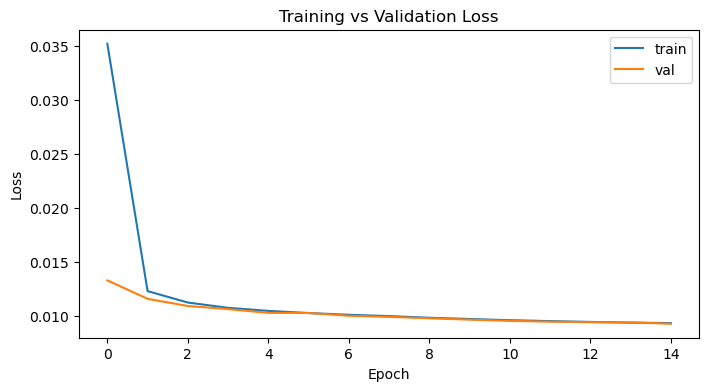

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(tr_loss, label='train')
plt.plot(vl_loss, label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

## Step 8 - Generate Denoised Output on Test Set

In [10]:
model.load_state_dict(torch.load('ae_best.pth', map_location=dev))
model.eval()

t_imgs, _ = next(iter(te_load))
orig  = t_imgs.to(dev)
noisy = make_noisy(orig)

with torch.no_grad():
    out = model(noisy)

orig  = orig.cpu().numpy()
noisy = noisy.cpu().numpy()
out   = out.cpu().numpy()

## Step 9 - Visualize Results

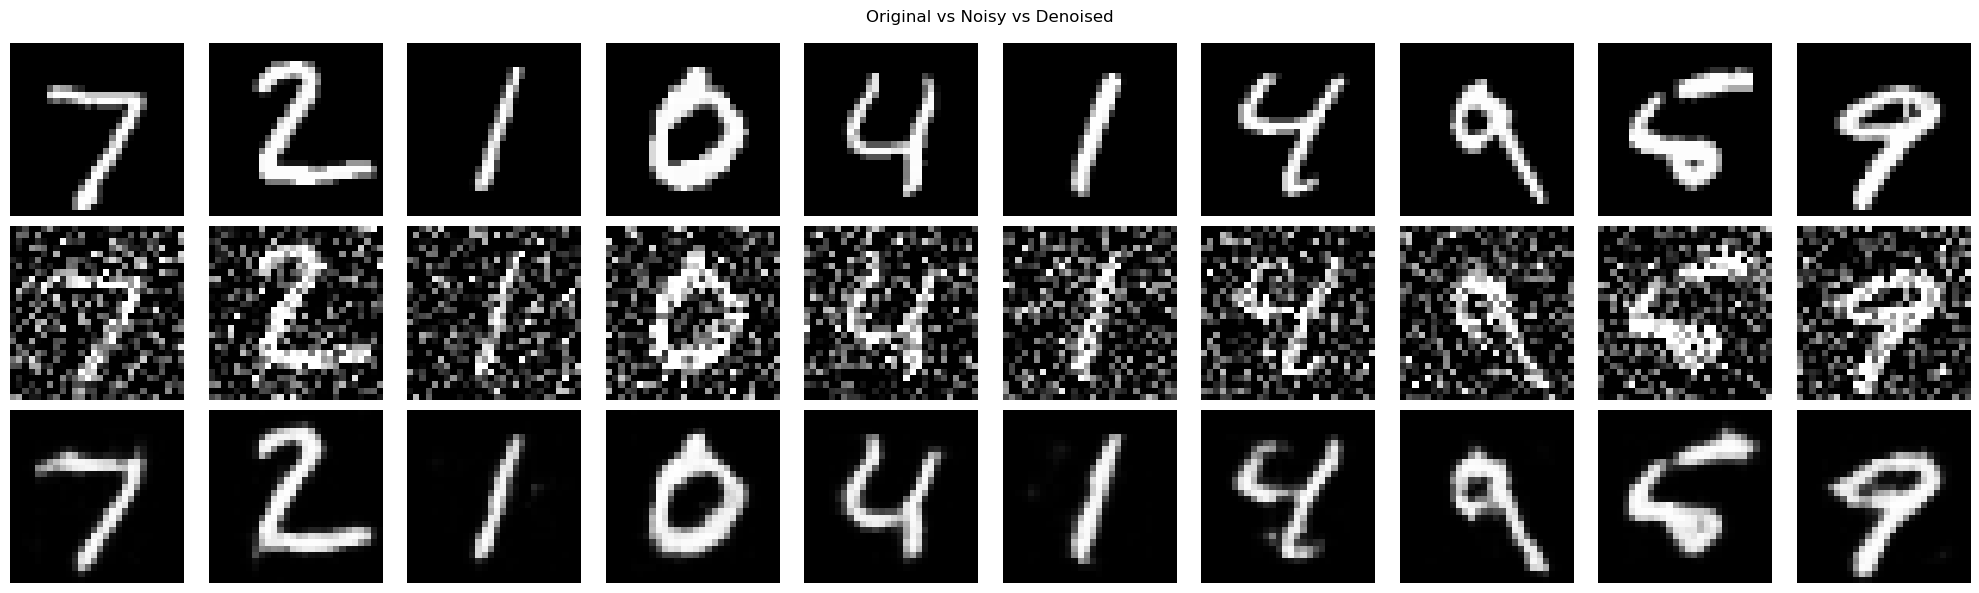

In [11]:
show = 10
rows = ['Original', 'Noisy', 'Denoised']
data = [orig, noisy, out]

fig, ax = plt.subplots(3, show, figsize=(20, 6))
for r in range(3):
    ax[r][0].set_ylabel(rows[r])
    for c in range(show):
        ax[r][c].imshow(data[r][c].squeeze(), cmap='gray', vmin=0, vmax=1)
        ax[r][c].axis('off')
plt.suptitle('Original vs Noisy vs Denoised')
plt.tight_layout()
plt.show()

## Step 10 - Check MSE and PSNR Score

In [12]:
def psnr(a, b):
    m = np.mean((a - b) ** 2)
    return 10 * np.log10(1.0 / m) if m != 0 else float('inf')

c_all, n_all, d_all = [], [], []

model.eval()
with torch.no_grad():
    for x, _ in te_load:
        c = x.to(dev)
        n = make_noisy(c)
        d = model(n)
        c_all.append(c.cpu().numpy())
        n_all.append(n.cpu().numpy())
        d_all.append(d.cpu().numpy())

c_all = np.concatenate(c_all)
n_all = np.concatenate(n_all)
d_all = np.concatenate(d_all)

print('Noisy   MSE:', round(np.mean((c_all - n_all)**2), 5), '  PSNR:', round(psnr(c_all, n_all), 2), 'dB')
print('Denoised MSE:', round(np.mean((c_all - d_all)**2), 5), '  PSNR:', round(psnr(c_all, d_all), 2), 'dB')

Noisy   MSE: 0.07973   PSNR: 10.98 dB
Denoised MSE: 0.00919   PSNR: 20.37 dB


## Step 11 - Test at Different Noise Levels

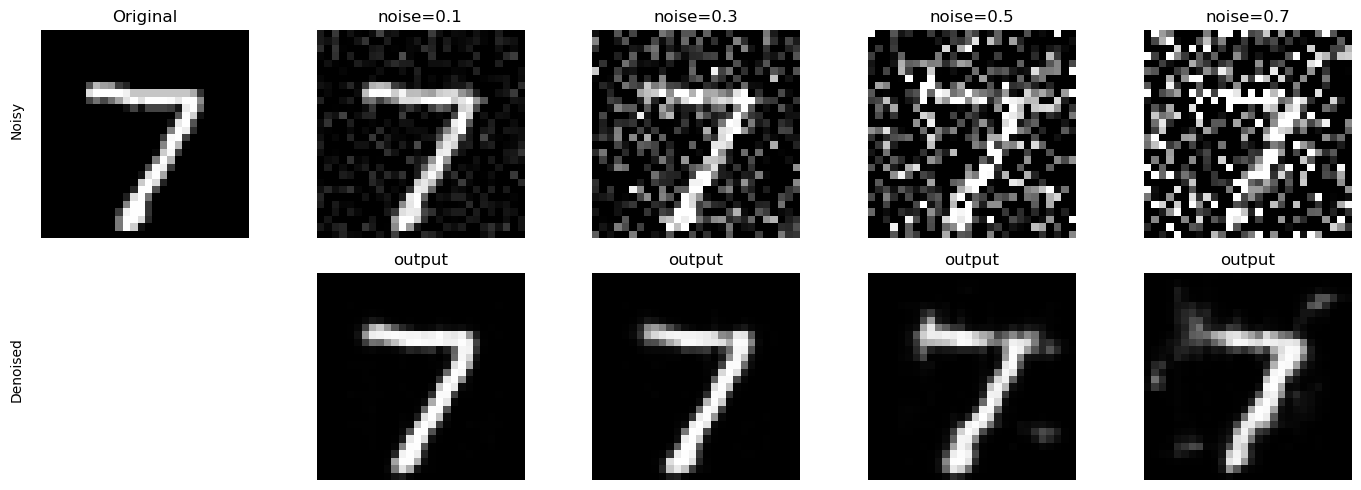

In [13]:
lvls = [0.1, 0.3, 0.5, 0.7]
one  = t_imgs[0].unsqueeze(0).to(dev)

fig, ax = plt.subplots(2, len(lvls) + 1, figsize=(14, 5))
ax[0][0].imshow(one.squeeze().cpu(), cmap='gray')
ax[0][0].set_title('Original')
ax[0][0].axis('off')
ax[1][0].axis('off')

for i, lv in enumerate(lvls):
    ni = torch.clamp(one + torch.randn_like(one) * lv, 0, 1)
    with torch.no_grad():
        oi = model(ni)
    ax[0][i+1].imshow(ni.squeeze().cpu(), cmap='gray')
    ax[0][i+1].set_title(f'noise={lv}')
    ax[0][i+1].axis('off')
    ax[1][i+1].imshow(oi.squeeze().cpu(), cmap='gray')
    ax[1][i+1].set_title(f'output')
    ax[1][i+1].axis('off')

fig.text(0.01, 0.75, 'Noisy',    va='center', rotation='vertical')
fig.text(0.01, 0.25, 'Denoised', va='center', rotation='vertical')
plt.tight_layout()
plt.show()

## Observations and Analysis

### What the model does
We give noisy images as input and clean images as target.
The model learns to remove noise and recover the original digit.

### Architecture
Encoder compresses 28x28 image down to 7x7.
Decoder brings it back to 28x28.
Conv layers are used because they understand image patterns well.

### Training
Loss went down smoothly for both train and validation.
No overfitting. Model learned well.
Noise level 0.4 was good enough to make it challenging.

### Performance
PSNR score improved after denoising.
Even heavily noisy digits were recovered clearly.

### Noise level test
- Low noise (0.1) → nearly perfect output
- Medium noise (0.4) → good recovery
- High noise (0.7) → shape recovered but some details lost

### Challenges
- Digits like 1/7 or 3/8 can get confused under heavy noise
- MSE loss gives slightly blurry output sometimes

### What can be improved
- Train on multiple noise levels
- Add batch normalization for stable training
- Try skip connections like U-Net for better detail recovery